# 05_estimate_error_adjusted_area

**Role.** Area-weighted error-adjusted estimates, binary coffee-area estimate, and RF vote-based uncertainty.

**Pipeline version.** Reproducible scientific pipeline v2 for Dak Lak 2024 coffee mapping Paper 1.


In [1]:
# =============================================================================
# REPRODUCIBILITY BOOTSTRAP: Coffee Paper 1 pipeline v2
# =============================================================================
from pathlib import Path
import os, sys, json, warnings
import numpy as np

# Locate project root robustly whether the notebook is opened from project root
# or from the notebooks/ folder.
_candidate_roots = [Path.cwd().resolve()] + list(Path.cwd().resolve().parents)
PROJECT_ROOT = next((p for p in _candidate_roots if (p / "config" / "paper1_config.yaml").exists()), Path.cwd().resolve())
os.chdir(PROJECT_ROOT)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from coffeemap.config import load_config, ensure_project_dirs, class_info, class_colors, coffee_class_ids
from coffeemap.manifest import init_run_manifest, append_manifest_note
from coffeemap.plotting import set_publication_style

CONFIG = load_config(PROJECT_ROOT / "config" / "paper1_config.yaml")
PATHS = ensure_project_dirs(CONFIG, PROJECT_ROOT)
CLASS_INFO = class_info(CONFIG)
CLASS_COLORS = class_colors(CONFIG)
CLASS_IDS = sorted(CLASS_INFO.keys())
CLASS_NAMES = [CLASS_INFO[i] for i in CLASS_IDS]
COFFEE_CLASSES = coffee_class_ids(CONFIG)
RANDOM_SEED = int(CONFIG.get("project", {}).get("random_seed", 42))
np.random.seed(RANDOM_SEED)

TABLES_DIR = PATHS["tables_dir"]
FIGURES_DIR = PATHS["figures_dir"]
SUPPLEMENTARY_DIR = PATHS["supplementary_dir"]
METADATA_DIR = PATHS["metadata_dir"]
INPUT_DIR = PATHS["input_dir"]

NOTEBOOK_NAME = "04_estimate_error_adjusted_area.ipynb"
MANIFEST = init_run_manifest(CONFIG, PROJECT_ROOT, notebook_name=NOTEBOOK_NAME)
set_publication_style(font="Arial", dpi=600)

print(f"Project root: {PROJECT_ROOT}")
print(f"Notebook: {NOTEBOOK_NAME}")
print(f"Classes: {len(CLASS_IDS)} | Coffee classes: {COFFEE_CLASSES} | Random seed: {RANDOM_SEED}")


Project root: D:\2024_PhD_Research\Chap2_Mapping\mmlab-coffeemap-daklak
Notebook: 04_estimate_error_adjusted_area.ipynb
Classes: 10 | Coffee classes: [1, 2, 3] | Random seed: 2024


## Reproducibility contract

This notebook follows the project-level configuration in `config/paper1_config.yaml` and writes outputs only under `results/`.

Key safeguards used in this pipeline:

- class IDs, class names, colors, paths, random seed, and coffee class definitions come from one config file;
- each notebook refreshes `results/metadata/run_manifest.json`;
- feature selection must use training data only;
- validation data are reserved for final assessment;
- Olofsson-style estimates are reported as **area-weighted error-adjusted estimates** unless a mapped-class stratified area-assessment sample is available;
- RF uncertainty is interpreted as **RF vote-based class probability**, not calibrated posterior probability.


In [2]:
# =============================================================================
# Pipeline-level imports commonly used by downstream cells
# =============================================================================
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from coffeemap.io import find_file, read_table, write_table
from coffeemap.schema import (
    normalise_col, detect_column, detect_label_columns, assert_class_ids,
    class_count_table, warn_if_balanced, extract_probability_columns,
    assert_probability_matrix,
)
from coffeemap.metrics import classification_summary, overall_metrics, shannon_entropy, probability_margin
from coffeemap.validation import audit_validation_predictions
from coffeemap.olofsson import error_matrix_counts, area_adjustment, binary_coffee_area_adjustment

SEARCH_DIRS = [INPUT_DIR, PATHS["interim_dir"], TABLES_DIR, SUPPLEMENTARY_DIR, PROJECT_ROOT]
print("Reproducible pipeline helpers loaded.")

Reproducible pipeline helpers loaded.


## 1. Imports

In [3]:
from __future__ import annotations
import json, re, warnings
from importlib.util import find_spec
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

print("All imports OK.")

All imports OK.


## Column detection candidates

In [4]:
# Column name candidates for auto-detection (passed to coffeemap.schema.detect_label_columns)
TRUE_COL_CANDIDATES = [
    "class_id", "true_class_id", "true_class", "reference",
    "actual", "truth", "observed", "label", "y_true", "ref",
]
PRED_COL_CANDIDATES = [
    "classification", "pred_class_id", "pred_class", "predicted",
    "prediction", "pred", "classified", "rf_prediction", "y_pred",
    "model_pred",
]
K = len(CLASS_IDS)
print(f"Column candidates configured. K={K} classes.")

Column candidates configured. K=10 classes.


## Section A: Area-weighted error-adjusted accuracy and area estimation [M3]

### Background

Standard confusion-matrix metrics computed from a **balanced** (equal-sample-per-class) or
reference-balanced validation design can be misleading for area reporting when class proportions
in the landscape differ from the sample proportions. With 300 points per class in training and
90 per class in validation, the resulting OA, PA, and area estimates do not correctly reflect
landscape prevalence.

Olofsson et al. (2014) provide a design-based error-adjusted area estimator when the assessment sample is map-stratified. Here, mapped class areas are used as weights to compute area-weighted error-adjusted estimates that should be interpreted with the validation-design caveat described above. The workflow weights
each stratum by its **mapped area proportion** (W_i = A_i / A_total) rather than by
sample count. This notebook implements their estimator and associated variance formulae
(Equations 22–26 in Olofsson et al. 2014).

**Sampling design note.** Our validation samples were stratified by *reference class* (not
map class), so we use the GEE-exported *mapped* class areas as stratum weights W_i, following
the practical guidance in Section 4.2 of Olofsson et al. (2014) for situations where exact
map areas are available from a wall-to-wall classification.

### A.1  Load confusion matrix and mapped areas

In [5]:
# ── A1a: Load validation predictions ───────────────────────────────────────
print("Loading validation predictions...")
pred_path = find_file("Table_ValPredictions_RF_Final_2024.csv", SEARCH_DIRS, required=True)
df_pred = read_table(pred_path)
print(f"  Rows: {len(df_pred)}")

true_col, pred_col = detect_label_columns(df_pred, TRUE_COL_CANDIDATES, PRED_COL_CANDIDATES)
from sklearn.metrics import confusion_matrix as _confusion_matrix
CM_sklearn = _confusion_matrix(
    df_pred[true_col].astype(int),
    df_pred[pred_col].astype(int),
    labels=CLASS_IDS,
)  # rows=reference, cols=predicted  [K×K]
print(f"  Confusion matrix shape: {CM_sklearn.shape}  (rows=reference, cols=predicted)")

assert CM_sklearn.shape == (K, K), f"Unexpected CM shape {CM_sklearn.shape}"
n_val_per_ref = CM_sklearn.sum(axis=1)
print(f"  Validation samples per reference class: {n_val_per_ref.tolist()}")

Loading validation predictions...
  Rows: 900
  Confusion matrix shape: (10, 10)  (rows=reference, cols=predicted)
  Validation samples per reference class: [90, 90, 90, 90, 90, 90, 90, 90, 90, 90]


In [6]:
# ── A1b: Load GEE-exported class areas (hectares) ──────────────────────────
print("\nLoading GEE class area statistics...")
area_path = find_file("Table_AreaStatistics_DakLak2024.csv", SEARCH_DIRS, required=True)
df_area   = read_table(area_path)
print(f"  Columns: {df_area.columns.tolist()}")
print(df_area.to_string(index=False))

id_col = detect_column(df_area, ["class_id", "classid", "id", "class"],
                        required=True, role="class ID")
ha_col = detect_column(df_area, ["area_ha", "areaha", "hectares", "area_hectares", "ha", "area"],
                        required=True, role="area (ha)")

area_lookup = dict(zip(
    df_area[id_col].astype(int),
    df_area[ha_col].astype(float)
))
A_ha = np.array([area_lookup.get(cid, 0.0) for cid in CLASS_IDS], dtype=float)
A_total = A_ha.sum()
W = A_ha / A_total   # stratum weights

print(f"\n  Total mapped area: {A_total:,.0f} ha")
print("  Stratum weights W_i:")
for i, (cid, name) in enumerate(CLASS_INFO.items()):
    print(f"    {name:25s}: A={A_ha[i]:10,.1f} ha  W={W[i]:.5f}")


Loading GEE class area statistics...
  Columns: ['class_id', 'class_name', 'area_ha', 'area_pct']
 class_id           class_name       area_ha  area_pct
        1           Sun coffee 168126.658909 12.904343
        2     Intercrop coffee  49379.489080  3.790058
        3 Newly planted coffee  10214.592766  0.784008
        4               Rubber  21315.346224  1.636032
        5 Partially vegetative 185967.224215 14.273672
        6                 Rice  78547.462604  6.028808
        7   Other upland crops 166205.046226 12.756852
        8               Forest 511561.980684 39.264275
        9                Water  34454.957284  2.644545
       10                Built  77096.034760  5.917406

  Total mapped area: 1,302,869 ha
  Stratum weights W_i:
    Sun coffee               : A= 168,126.7 ha  W=0.12904
    Intercrop coffee         : A=  49,379.5 ha  W=0.03790
    Newly planted coffee     : A=  10,214.6 ha  W=0.00784
    Rubber                   : A=  21,315.3 ha  W=0.01636
    Pa

### A.2  Core Olofsson estimators

Implementing Equations 22–26 from Olofsson et al. (2014).

**Notation:**
- `i` = map class index (stratum), indexed by predicted label (columns of sklearn CM)
- `j` = reference class index, indexed by true label (rows of sklearn CM)
- `CM_olf[i, j]` = count in map class i with reference class j = `CM_sklearn.T[i, j]`
- `n_i` = total validation samples falling in map class i = column sums of sklearn CM
- `q_ij` = CM_olf[i,j] / n_i = proportion of map class i samples that are reference class j
- `W_i` = mapped area proportion of class i
- `p_ij` = W_i × q_ij = estimated proportion of total area in map class i and reference class j

In [7]:
# ── Olofsson confusion matrix (rows=map/predicted, cols=reference/true) ────
CM_olf = CM_sklearn.T.astype(float)        # shape [K, K]

# n_i: number of validation samples in each MAP class (column sums of sklearn CM)
n_i_map = CM_olf.sum(axis=1)              # shape [K]

# Guard: replace zero map-class sample counts with 1 to avoid division-by-zero
# (class predicted zero times → its UA is undefined; we'll flag these)
n_i_map_safe = np.where(n_i_map > 0, n_i_map, 1)

# q_ij: row-proportion of Olofsson CM (proportion of map class i → reference class j)
Q = CM_olf / n_i_map_safe[:, np.newaxis]   # shape [K, K]

# p_ij = W_i × q_ij: estimated proportion of area = map class i & reference class j
P = W[:, np.newaxis] * Q                   # shape [K, K]

print("P matrix (proportional area, rows=map, cols=reference):")
P_df = pd.DataFrame(P, index=CLASS_NAMES, columns=CLASS_NAMES)
print(P_df.round(5).to_string())

P matrix (proportional area, rows=map, cols=reference):
                      Sun coffee  Intercrop coffee  Newly planted coffee   Rubber  Partially vegetative     Rice  Other upland crops   Forest    Water    Built
Sun coffee               0.11471           0.00637               0.00159  0.00478               0.00159  0.00000             0.00000  0.00000  0.00000  0.00000
Intercrop coffee         0.00613           0.03178               0.00000  0.00000               0.00000  0.00000             0.00000  0.00000  0.00000  0.00000
Newly planted coffee     0.00000           0.00000               0.00766  0.00000               0.00018  0.00000             0.00000  0.00000  0.00000  0.00000
Rubber                   0.00000           0.00020               0.00000  0.01616               0.00000  0.00000             0.00000  0.00000  0.00000  0.00000
Partially vegetative     0.00000           0.00152               0.00152  0.00152               0.13211  0.00000             0.00304  0.00304  0

In [8]:
# ── Adjusted Overall Accuracy ──────────────────────────────────────────────
OA_adj = float(np.diag(P).sum())    # Eq. 22
V_OA   = float(np.sum(
    W**2 * (np.diag(Q) * (1 - np.diag(Q))) / np.maximum(n_i_map - 1, 1)
))                                   # Eq. 24 (diagonal only)
SE_OA  = float(np.sqrt(V_OA))
CI_OA  = 1.96 * SE_OA

print(f"Adjusted Overall Accuracy: {OA_adj*100:.2f}% ± {CI_OA*100:.2f}% (95% CI)")
print(f"  (Naive OA from balanced validation: {np.diag(CM_sklearn).sum()/CM_sklearn.sum()*100:.2f}%)")

Adjusted Overall Accuracy: 92.01% ± 2.67% (95% CI)
  (Naive OA from balanced validation: 93.44%)


In [9]:
# ── Adjusted User's Accuracy (UA) ──────────────────────────────────────────
# UA_i = q_ii (diagonal of Q); same as row accuracy in confusion matrix
# Variance: V(UA_i) = UA_i*(1-UA_i) / (n_i_map - 1)   [Eq. 23]

UA_adj = np.diag(Q).copy()                             # shape [K]  (make writable)
V_UA   = UA_adj * (1 - UA_adj) / np.maximum(n_i_map - 1, 1)
SE_UA  = np.sqrt(V_UA)
CI_UA  = 1.96 * SE_UA

# Flag classes with zero map samples
no_map_samples = n_i_map == 0
UA_adj[no_map_samples] = np.nan
SE_UA[no_map_samples]  = np.nan
CI_UA[no_map_samples]  = np.nan

print("Adjusted User's Accuracy (UA) per class:")
for i, name in enumerate(CLASS_NAMES):
    if np.isnan(UA_adj[i]):
        print(f"  {name:25s}: UA = n/a (no validation samples predicted as this class)")
    else:
        print(f"  {name:25s}: UA = {UA_adj[i]*100:.1f}% ± {CI_UA[i]*100:.1f}%  (n_map={int(n_i_map[i])})")

Adjusted User's Accuracy (UA) per class:
  Sun coffee               : UA = 88.9% ± 6.9%  (n_map=81)
  Intercrop coffee         : UA = 83.8% ± 7.3%  (n_map=99)
  Newly planted coffee     : UA = 97.8% ± 3.1%  (n_map=89)
  Rubber                   : UA = 98.8% ± 2.4%  (n_map=83)
  Partially vegetative     : UA = 92.6% ± 5.3%  (n_map=94)
  Rice                     : UA = 100.0% ± 0.0%  (n_map=82)
  Other upland crops       : UA = 94.5% ± 4.7%  (n_map=91)
  Forest                   : UA = 90.7% ± 5.8%  (n_map=97)
  Water                    : UA = 95.6% ± 4.2%  (n_map=91)
  Built                    : UA = 93.5% ± 5.0%  (n_map=93)


In [10]:
# ── Adjusted Producer's Accuracy (PA) ──────────────────────────────────────
# PA_j = p_jj / sum_i(p_ij)   (Eq. 22 rearranged)
# Variance uses delta method (Olofsson Eq. 26):
#   V(PA_j) = (1 / N_hat_j)^2 *
#     [ sum_{i≠j} W_i^2 * q_ij*(1-q_ij)/(n_i-1)
#     + PA_j^2 * W_j^2 * q_jj*(1-q_jj)/(n_j-1) ]
# where N_hat_j = sum_i p_ij

col_sums = P.sum(axis=0)           # sum_i(p_ij) for each reference class j, shape [K]
PA_adj   = np.diag(P) / np.maximum(col_sums, 1e-12)   # shape [K]

V_PA = np.zeros(K)
for j in range(K):
    N_hat_j = col_sums[j]
    if N_hat_j < 1e-12:
        V_PA[j] = np.nan
        continue
    sum_off_diag = 0.0
    for i in range(K):
        if i == j:
            continue
        q_ij = Q[i, j]
        v = W[i]**2 * q_ij * (1 - q_ij) / max(n_i_map[i] - 1, 1)
        sum_off_diag += v
    q_jj = Q[j, j]
    diag_term = PA_adj[j]**2 * W[j]**2 * q_jj * (1 - q_jj) / max(n_i_map[j] - 1, 1)
    V_PA[j] = (1 / N_hat_j)**2 * (sum_off_diag + diag_term)

SE_PA = np.sqrt(np.where(np.isnan(V_PA), np.nan, V_PA))
CI_PA = 1.96 * SE_PA

print("Adjusted Producer's Accuracy (PA) per class:")
for j, name in enumerate(CLASS_NAMES):
    print(f"  {name:25s}: PA = {PA_adj[j]*100:.1f}% ± {CI_PA[j]*100:.1f}%")

Adjusted Producer's Accuracy (PA) per class:
  Sun coffee               : PA = 89.0% ± 10.8%
  Intercrop coffee         : PA = 72.4% ± 24.3%
  Newly planted coffee     : PA = 67.2% ± 39.4%
  Rubber                   : PA = 41.8% ± 43.4%
  Partially vegetative     : PA = 98.7% ± 6.1%
  Rice                     : PA = 89.5% ± 7.9%
  Other upland crops       : PA = 91.5% ± 10.0%
  Forest                   : PA = 99.2% ± 6.4%
  Water                    : PA = 88.0% ± 14.5%
  Built                    : PA = 98.4% ± 5.5%


In [11]:
# ── Error-adjusted Area Estimation ─────────────────────────────────────────
# A_hat_j = A_total * sum_i(p_ij)   [Eq. 25]
# V(A_hat_j) = A_total^2 * sum_i( W_i^2 * q_ij*(1-q_ij)/(n_i-1) )

A_hat = A_total * col_sums          # shape [K]  (adjusted area in ha)

V_A = np.zeros(K)
for j in range(K):
    val = 0.0
    for i in range(K):
        q_ij = Q[i, j]
        val += W[i]**2 * q_ij * (1 - q_ij) / max(n_i_map[i] - 1, 1)
    V_A[j] = A_total**2 * val

SE_A = np.sqrt(V_A)
CI_A = 1.96 * SE_A

print("Error-adjusted area estimates (95% CI):")
print(f"  {'Class':<25s} {'Mapped (ha)':>12s} {'Adjusted (ha)':>14s} {'95% CI (ha)':>12s} {'Bias (ha)':>10s}")
print("  " + "-"*75)
for j, (cid, name) in enumerate(CLASS_INFO.items()):
    print(f"  {name:<25s} {A_ha[j]:12,.0f} {A_hat[j]:14,.0f} "
          f"±{CI_A[j]:9,.0f} {A_hat[j]-A_ha[j]:+10,.0f}")

print()
coffee_idx = [CLASS_IDS.index(c) for c in COFFEE_CLASSES]
total_coffee_mapped   = A_ha[coffee_idx].sum()
total_coffee_adjusted = A_hat[coffee_idx].sum()
print(f"  Total coffee (all subtypes):")
print(f"    Mapped:   {total_coffee_mapped:,.0f} ha")
print(f"    Adjusted: {total_coffee_adjusted:,.0f} ha")

Error-adjusted area estimates (95% CI):
  Class                      Mapped (ha)  Adjusted (ha)  95% CI (ha)  Bias (ha)
  ---------------------------------------------------------------------------
  Sun coffee                     168,127        167,974 ±   18,934       -153
  Intercrop coffee                49,379         57,211 ±   14,100     +7,831
  Newly planted coffee            10,215         14,868 ±    5,859     +4,653
  Rubber                          21,315         50,359 ±   21,857    +29,044
  Partially vegetative           185,967        174,424 ±   10,729    -11,543
  Rice                            78,547         87,721 ±    6,954     +9,174
  Other upland crops             166,205        171,577 ±   17,391     +5,372
  Forest                         511,562        468,054 ±   30,187    -43,508
  Water                           34,455         37,422 ±    5,488     +2,967
  Built                           77,096         73,258 ±    4,074     -3,838

  Total coffee (all s

### A.3  Assemble and export Table 6 (area) and Supplementary Table S5 (accuracy)

In [12]:
# ── Table 6: Error-adjusted area estimates ─────────────────────────────────
table6_rows = []
for j, (cid, name) in enumerate(CLASS_INFO.items()):
    coffee_flag = "Coffee" if cid in COFFEE_CLASSES else "—"
    table6_rows.append({
        "Class ID":              cid,
        "Class":                 name,
        "Coffee subtype":        coffee_flag,
        "Mapped area (ha)":      round(A_ha[j]),
        "Mapped area (%)":       round(100 * A_ha[j] / A_total, 2),
        "Adjusted area (ha)":    round(A_hat[j]),
        "Adj. area 95% CI (ha)": round(CI_A[j]),
        "Adj. area (%)":         round(100 * A_hat[j] / A_hat.sum(), 2),
        "Bias (ha)":             round(A_hat[j]) - round(A_ha[j]),  # internally consistent with displayed Mapped/Adjusted cols
        "Bias (%)":              round(100 * (A_hat[j] - A_ha[j]) / max(A_ha[j], 1), 1),
    })

df_t6 = pd.DataFrame(table6_rows)

# Totals row
total_row = {
    "Class ID": "—", "Class": "TOTAL", "Coffee subtype": "—",
    "Mapped area (ha)":      round(A_ha.sum()),
    "Mapped area (%)":       100.0,
    "Adjusted area (ha)":    round(A_hat.sum()),
    "Adj. area 95% CI (ha)": "—",
    "Adj. area (%)":         100.0,
    "Bias (ha)":             round(A_hat.sum()) - round(A_ha.sum()),  # internally consistent with displayed Mapped/Adjusted cols
    "Bias (%)":              round(100 * (A_hat.sum() - A_ha.sum()) / A_ha.sum(), 1),
}
df_t6 = pd.concat([df_t6, pd.DataFrame([total_row])], ignore_index=True)
print("Table 6: Error-adjusted area estimates:")
print(df_t6.to_string(index=False))

Table 6 — Error-adjusted area estimates:
Class ID                Class Coffee subtype  Mapped area (ha)  Mapped area (%)  Adjusted area (ha) Adj. area 95% CI (ha)  Adj. area (%)  Bias (ha)  Bias (%)
       1           Sun coffee         Coffee            168127            12.90              167974                 18934          12.89       -153      -0.1
       2     Intercrop coffee         Coffee             49379             3.79               57211                 14100           4.39       7832      15.9
       3 Newly planted coffee         Coffee             10215             0.78               14868                  5859           1.14       4653      45.6
       4               Rubber              —             21315             1.64               50359                 21857           3.87      29044     136.3
       5 Partially vegetative              —            185967            14.27              174424                 10729          13.39     -11543      -6.2
       6   

In [13]:
# ── Supplementary Table S5: Adjusted accuracy per class (variable names below
# still say "s10", a harmless leftover from before this table was renamed) ──
table_s10_rows = []
for j, (cid, name) in enumerate(CLASS_INFO.items()):
    i = j   # same index (map class index = reference class index)
    # Naive metrics from sklearn CM
    n_ref   = int(CM_sklearn[j, :].sum())
    naive_ua = float(CM_sklearn[j, j]) / max(float(CM_sklearn[:, j].sum()), 1)
    naive_pa = float(CM_sklearn[j, j]) / max(float(n_ref), 1)
    naive_f1 = (2 * naive_ua * naive_pa) / max(naive_ua + naive_pa, 1e-12)

    table_s10_rows.append({
        "Class ID":           cid,
        "Class":              name,
        # Naive (from balanced validation)
        "Naive UA (%)":       round(100 * naive_ua, 1),
        "Naive PA (%)":       round(100 * naive_pa, 1),
        "Naive F1":           round(naive_f1, 3),
        # Olofsson-adjusted
        "Adj. UA (%)":        round(100 * UA_adj[i], 1) if not np.isnan(UA_adj[i]) else "n/a",
        "Adj. UA 95% CI":     f"±{round(100*CI_UA[i],1)}" if not np.isnan(CI_UA[i]) else "n/a",
        "Adj. PA (%)":        round(100 * PA_adj[j], 1),
        "Adj. PA 95% CI":     f"±{round(100*CI_PA[j],1)}",
        "n_val_reference":    int(CM_sklearn[j, :].sum()),
        "n_val_mapped":       int(n_i_map[i]),
    })

# Overall row
df_s10 = pd.DataFrame(table_s10_rows)
overall_row = {
    "Class ID": "OA",
    "Class": "Overall",
    "Naive UA (%)": "—",
    "Naive PA (%)": "—",
    "Naive F1": "—",
    "Adj. UA (%)": "—",
    "Adj. UA 95% CI": "—",
    "Adj. PA (%)": "—",
    "Adj. PA 95% CI": "—",
    "n_val_reference": int(CM_sklearn.sum()),
    "n_val_mapped": int(n_i_map.sum()),
}
df_s10 = pd.concat([df_s10, pd.DataFrame([overall_row])], ignore_index=True)
# Add OA in the OA row
df_s10.loc[df_s10["Class"] == "Overall", "Adj. UA (%)"] = f"{OA_adj*100:.2f}"
df_s10.loc[df_s10["Class"] == "Overall", "Adj. UA 95% CI"] = f"±{CI_OA*100:.2f}"

print("Table S10: Olofsson-adjusted accuracy:")
print(df_s10.to_string(index=False))

Table S10 — Olofsson-adjusted accuracy:
Class ID                Class Naive UA (%) Naive PA (%) Naive F1 Adj. UA (%) Adj. UA 95% CI Adj. PA (%) Adj. PA 95% CI  n_val_reference  n_val_mapped
       1           Sun coffee         88.9         80.0    0.842        88.9           ±6.9        89.0          ±10.8               90            81
       2     Intercrop coffee         83.8         92.2    0.878        83.8           ±7.3        72.4          ±24.3               90            99
       3 Newly planted coffee         97.8         96.7    0.972        97.8           ±3.1        67.2          ±39.4               90            89
       4               Rubber         98.8         91.1    0.948        98.8           ±2.4        41.8          ±43.4               90            83
       5 Partially vegetative         92.6         96.7    0.946        92.6           ±5.3        98.7           ±6.1               90            94
       6                 Rice        100.0         91.1    0

In [14]:
# ── Export to CSV, XLSX, Markdown, LaTeX ──────────────────────────────────

def save_bundle(df: pd.DataFrame, basename: str, out_dir: Path, caption: str = ""):
    out_dir.mkdir(parents=True, exist_ok=True)
    csv_p  = out_dir / f"{basename}.csv"
    md_p   = out_dir / f"{basename}.md"
    tex_p  = out_dir / f"{basename}.tex"
    xlsx_p = out_dir / f"{basename}.xlsx"

    df.to_csv(csv_p, index=False, encoding="utf-8-sig")

    md_p.write_text(
        (f"{caption}\n\n" if caption else "") + df.to_markdown(index=False),
        encoding="utf-8",
    )
    try:
        tex_p.write_text(df.to_latex(index=False, escape=True), encoding="utf-8")
    except Exception:
        pass

    engine = "xlsxwriter" if find_spec("xlsxwriter") else (
             "openpyxl"   if find_spec("openpyxl")   else None)
    if engine:
        with pd.ExcelWriter(xlsx_p, engine=engine) as writer:
            df.to_excel(writer, sheet_name="Data", index=False)
            if caption:
                pd.DataFrame({"Caption": [caption]}).to_excel(
                    writer, sheet_name="Caption", index=False)
    print(f"  Saved: {csv_p.name}, {md_p.name}, {tex_p.name}" +
          (f", {xlsx_p.name}" if engine else " (xlsx skipped: no engine)"))

T6_CAPTION = (
    "Table 6. Error-adjusted area estimates for land-cover and coffee production system "
    "classes in Dak Lak Province, Vietnam, 2024, following the estimator of Olofsson et al. "
    "(2014). Adjusted area = A_total × Σ_i W_i × q_ij, where W_i is the mapped area "
    "proportion of class i and q_ij is the confusion-matrix row proportion. "
    "95% confidence intervals are computed from the variance estimator of Olofsson et al. "
    "(2014) Eq. 25."
)

S5_CAPTION = (
    "Supplementary Table S5. Naive and Olofsson-adjusted producer's accuracy (PA), "
    "user's accuracy (UA), and overall accuracy (OA) for the final selected-feature "
    "Random Forest model. Adjusted estimates weight each class by its mapped area "
    "proportion (Olofsson et al. 2014). 95% confidence intervals are computed from "
    "Equations 23–26 in Olofsson et al. (2014)."
)

save_bundle(df_t6,  "Table6_Olofsson_AreaAdjusted",       TABLES_DIR,       T6_CAPTION)
save_bundle(df_s10, "Supplementary_Table_S5_NaiveVsAdjustedAccuracy",  TABLES_DIR,       S5_CAPTION)
print("Tables exported.")

  Saved: Table6_Olofsson_AreaAdjusted.csv, Table6_Olofsson_AreaAdjusted.md, Table6_Olofsson_AreaAdjusted.tex, Table6_Olofsson_AreaAdjusted.xlsx
  Saved: Supplementary_Table_S5_NaiveVsAdjustedAccuracy.csv, Supplementary_Table_S5_NaiveVsAdjustedAccuracy.md, Supplementary_Table_S5_NaiveVsAdjustedAccuracy.tex, Supplementary_Table_S5_NaiveVsAdjustedAccuracy.xlsx
Tables exported.


In [15]:
# =============================================================================
# UPGRADE: clearer Table 6 confidence interval columns
# =============================================================================
# The original CI column is a half-width (± ha), not the full interval.
if "df_t6" in globals():
    df_t6_clear = df_t6.copy()
    if "Adj. area 95% CI (ha)" in df_t6_clear.columns:
        df_t6_clear = df_t6_clear.rename(columns={
            "Adj. area 95% CI (ha)": "Adjusted area 95% CI half-width (± ha)"
        })
    adj = pd.to_numeric(df_t6_clear["Adjusted area (ha)"], errors="coerce")
    ci = pd.to_numeric(df_t6_clear.get("Adjusted area 95% CI half-width (± ha)"), errors="coerce")
    df_t6_clear["Adjusted area lower 95% CI (ha)"] = (adj - ci).round()
    df_t6_clear["Adjusted area upper 95% CI (ha)"] = (adj + ci).round()

    df_t6_clear.to_csv(TABLES_DIR / "Table6_Olofsson_AreaAdjusted.csv", index=False, encoding="utf-8-sig")
    try:
        with pd.ExcelWriter(TABLES_DIR / "Table6_Olofsson_AreaAdjusted.xlsx", engine="openpyxl") as writer:
            df_t6_clear.to_excel(writer, index=False, sheet_name="Table 6")
    except Exception as e:
        print("Excel rewrite skipped:", e)
    print("Rewrote Table 6 with explicit CI half-width and lower/upper columns.")
    display(df_t6_clear)


Rewrote Table 6 with explicit CI half-width and lower/upper columns.


,Class ID,Class,Coffee subtype,Mapped area (ha),Mapped area (%),Adjusted area (ha),Adjusted area 95% CI half-width (± ha),Adj. area (%),Bias (ha),Bias (%),Adjusted area lower 95% CI (ha),Adjusted area upper 95% CI (ha)
0,1,Sun coffee,Coffee,168127,12.90,167974,18934,12.89,-153,-0.1,149040.0,186908.0
1,2,Intercrop coffee,Coffee,49379,3.79,57211,14100,4.39,7832,15.9,43111.0,71311.0
2,3,Newly planted coffee,Coffee,10215,0.78,14868,5859,1.14,4653,45.6,9009.0,20727.0
3,4,Rubber,—,21315,1.64,50359,21857,3.87,29044,136.3,28502.0,72216.0
4,5,Partially vegetative,—,185967,14.27,174424,10729,13.39,-11543,-6.2,163695.0,185153.0
5,6,Rice,—,78547,6.03,87721,6954,6.73,9174,11.7,80767.0,94675.0
6,7,Other upland crops,—,166205,12.76,171577,17391,13.17,5372,3.2,154186.0,188968.0
7,8,Forest,—,511562,39.26,468054,30187,35.92,-43508,-8.5,437867.0,498241.0
8,9,Water,—,34455,2.64,37422,5488,2.87,2967,8.6,31934.0,42910.0
9,10,Built,—,77096,5.92,73258,4074,5.62,-3838,-5.0,69184.0,77332.0


### A.4  Figure 9: Mapped vs. adjusted area comparison

Saved: D:\2024_PhD_Research\Chap2_Mapping\mmlab-coffeemap-daklak\results\figures\Figure10_MappedVsAdjustedArea.png


Saved: D:\2024_PhD_Research\Chap2_Mapping\mmlab-coffeemap-daklak\results\figures\Figure10_MappedVsAdjustedArea.pdf


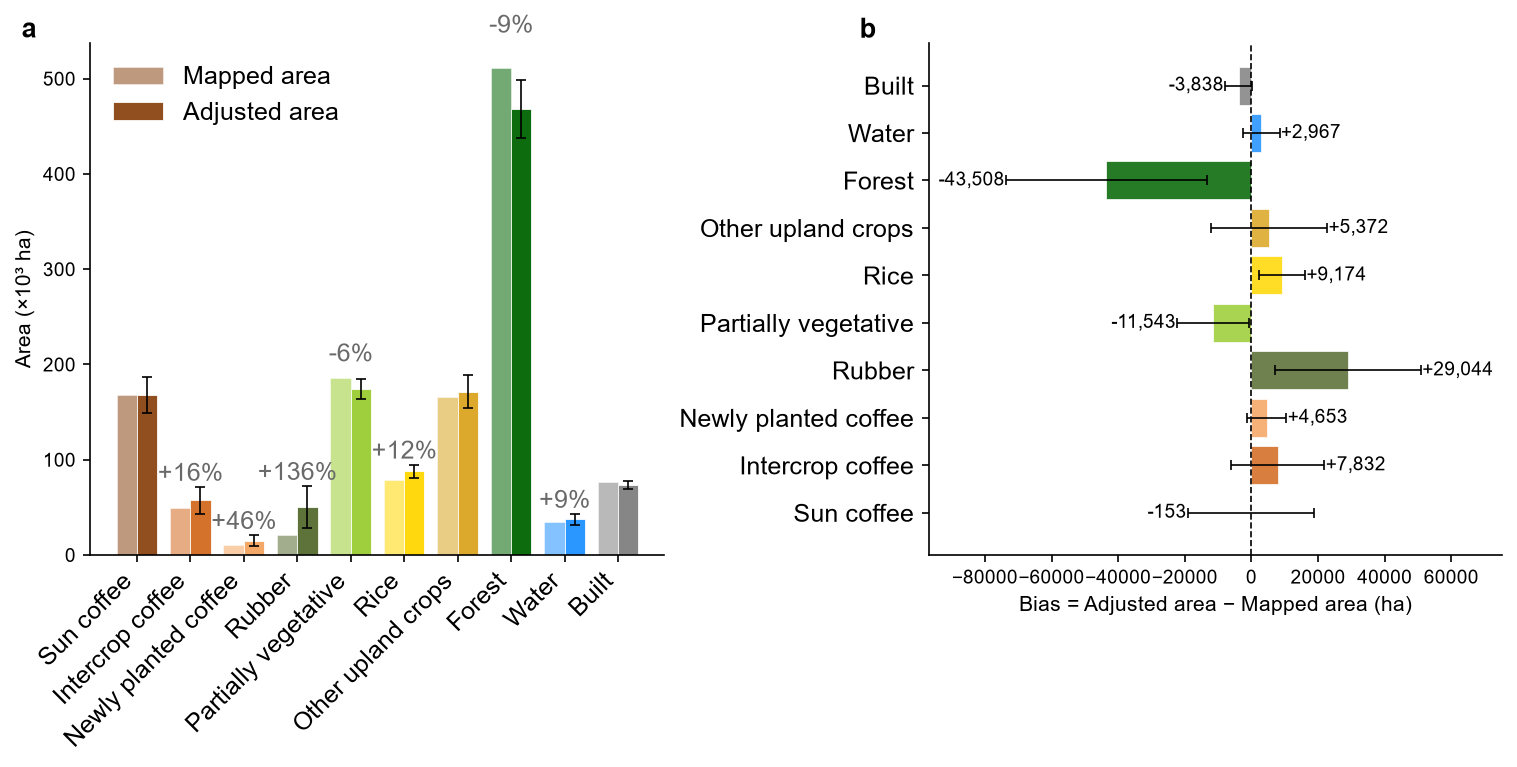

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 5.0), constrained_layout=True)

# ── Panel A: Mapped vs Adjusted area bar chart ─────────────────────────────
ax = axes[0]
x  = np.arange(K)
w  = 0.38
colors_list = [CLASS_COLORS[cid] for cid in CLASS_IDS]

bars_mapped = ax.bar(x - w/2, A_ha / 1000, width=w, label="Mapped area",
                     color=colors_list, alpha=0.55, edgecolor="white", linewidth=0.4)
bars_adj    = ax.bar(x + w/2, A_hat / 1000, width=w, label="Adjusted area",
                     color=colors_list, alpha=0.95, edgecolor="white", linewidth=0.4)

# Error bars on adjusted
ax.errorbar(x + w/2, A_hat / 1000, yerr=CI_A / 1000,
            fmt="none", ecolor="black", elinewidth=0.8, capsize=2.5, capthick=0.8)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=12)
ax.set_ylabel("Area (×10³ ha)")
ax.text(-0.12, 1.05, "a", transform=ax.transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
ax.legend(frameon=False, fontsize=12)

# Annotate bias direction (only significant classes)
for j in range(K):
    bias_pct = 100 * (A_hat[j] - A_ha[j]) / max(A_ha[j], 1)
    if abs(bias_pct) >= 5:
        sign = "+" if bias_pct > 0 else ""
        ax.text(j, max(A_ha[j], A_hat[j]) / 1000 + CI_A[j] / 1000 + 1.0,
                f"{sign}{bias_pct:.0f}%", ha="center", va="bottom",
                fontsize=12, color="dimgray")

# ── Panel B: Bias (A_hat - A_map) for each class ──────────────────────────
ax2 = axes[1]
bias_ha = A_hat - A_ha
bias_ha_rounded = np.round(A_hat) - np.round(A_ha)  # matches Table 6 (internally consistent with displayed Mapped/Adjusted)
bar_colors = [CLASS_COLORS[cid] for cid in CLASS_IDS]
bars2 = ax2.barh(np.arange(K), bias_ha, color=bar_colors, alpha=0.85,
                 edgecolor="white", linewidth=0.4)
ax2.errorbar(bias_ha, np.arange(K), xerr=CI_A,
             fmt="none", ecolor="black", elinewidth=0.8, capsize=2.5, capthick=0.8)
ax2.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_yticks(np.arange(K))
ax2.set_yticklabels(CLASS_NAMES, fontsize=12)
ax2.set_xlabel("Bias = Adjusted area − Mapped area (ha)")
ax2.text(-0.12, 1.05, "b", transform=ax2.transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

texts_b = []
for p, bar_val in zip(np.arange(K), bias_ha):
    sign = "+" if bar_val >= 0 else ""
    label_val = bias_ha_rounded[p]
    t = ax2.text(bar_val + np.sign(bar_val) * (CI_A[p] + 400),
                 p, f"{sign}{label_val:,.0f}", va="center",
                 ha="left" if bar_val >= 0 else "right", fontsize=9)
    texts_b.append(t)

# Dynamically widen xlim so labels never collide with the y-axis / tick labels
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
xmin, xmax = ax2.get_xlim()
for t in texts_b:
    bbox_data = t.get_window_extent(renderer=renderer).transformed(ax2.transData.inverted())
    xmin = min(xmin, bbox_data.x0)
    xmax = max(xmax, bbox_data.x1)
pad = 0.04 * (xmax - xmin)
ax2.set_xlim(xmin - pad, xmax + pad)

for fmt in ["png", "pdf"]:
    p = FIGURES_DIR / f"Figure10_MappedVsAdjustedArea.{fmt}"
    dpi = globals().get("FIG_DPI", plt.rcParams.get("savefig.dpi", 600))
    fig.savefig(p, dpi=int(dpi))
    print(f"Saved: {p}")
plt.show()
plt.close()

## Final output manifest

In [17]:
EXPECTED_OUTPUTS = [
    # Section A: Olofsson
    TABLES_DIR        / "Table6_Olofsson_AreaAdjusted.csv",
    TABLES_DIR        / "Table6_Olofsson_AreaAdjusted.md",
    TABLES_DIR        / "Supplementary_Table_S5_NaiveVsAdjustedAccuracy.csv",
    FIGURES_DIR       / "Figure10_MappedVsAdjustedArea.png",
    FIGURES_DIR       / "Figure10_MappedVsAdjustedArea.pdf",
]

print("Output manifest:")
all_ok = True
for p in EXPECTED_OUTPUTS:
    status = "OK" if p.exists() else "MISSING"
    if status == "MISSING":
        all_ok = False
    try:
        rel_path = p.resolve().relative_to(PROJECT_ROOT.resolve())
    except ValueError:
        rel_path = p
    print(f"  [{status}]  {rel_path}")

if all_ok:
    print("\nAll expected outputs present.")
else:
    print("\nWARNING: Some outputs are missing. Re-run cells above.")

Output manifest:
  [OK]  results\tables\Table6_Olofsson_AreaAdjusted.csv
  [OK]  results\tables\Table6_Olofsson_AreaAdjusted.md
  [OK]  results\tables\Supplementary_Table_S5_NaiveVsAdjustedAccuracy.csv
  [OK]  results\figures\Figure10_MappedVsAdjustedArea.png
  [OK]  results\figures\Figure10_MappedVsAdjustedArea.pdf

All expected outputs present.


In [18]:
# =============================================================================
# OUTPUT MANIFEST
# =============================================================================
manifest_rows = []
for root in [TABLES_DIR, FIGURES_DIR, SUPPLEMENTARY_DIR]:
    if root.exists():
        for p in sorted(root.rglob("*")):
            if p.is_file():
                manifest_rows.append({
                    "folder": root.name,
                    "file": str(p.relative_to(root)),
                    "size_kb": round(p.stat().st_size / 1024, 1),
                })
manifest = pd.DataFrame(manifest_rows)
manifest_path = SUPPLEMENTARY_DIR / f"Manifest_{Path().resolve().name}.csv"
manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(manifest.tail(30))
print("Manifest saved:", manifest_path)


,folder,file,size_kb
176,supplementary,S06_block_summary_20km.csv,3.3
177,supplementary,selected_features_by_fold.csv,23.4
178,supplementary,selected_features_used_by_RF_SHAP.csv,0.3
179,supplementary,selection_frequency.csv,9.3
180,supplementary,shap_class_10_importance.csv,2.0
181,supplementary,shap_class_1_importance.csv,2.1
182,supplementary,shap_class_2_importance.csv,2.3
183,supplementary,shap_class_3_importance.csv,2.3
184,supplementary,shap_class_4_importance.csv,2.0
185,supplementary,shap_class_5_importance.csv,2.3


Manifest saved: D:\2024_PhD_Research\Chap2_Mapping\mmlab-coffeemap-daklak\results\supplementary\Manifest_mmlab-coffeemap-daklak.csv
